# 02 — Similarity threshold analysis

## Goal

Đo ảnh hưởng của threshold lên chất lượng exact-sentence và sức khỏe đồ thị.

## Setup

Khởi tạo đường dẫn, module thuật toán và thư mục artifact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'data' / 'DUC_TEXT').is_dir():
            PROJECT_ROOT = candidate
            break

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'textrank-parameter-analysis'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from experiment_utils import *

TRAIN_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'test'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'textrank-parameter-analysis'
CSV_DIR = OUTPUT_DIR / 'csv'
CHART_DIR = OUTPUT_DIR / 'charts'
CSV_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project: {PROJECT_ROOT}')
print(f'Output : {OUTPUT_DIR}')

Project: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice
Output : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/textrank-parameter-analysis


## Steps

### 1. Inspect cosine-similarity distribution

{'P50': 0.0, 'P75': 0.0, 'P90': 0.04465505341471584, 'P95': 0.07623720891594923}


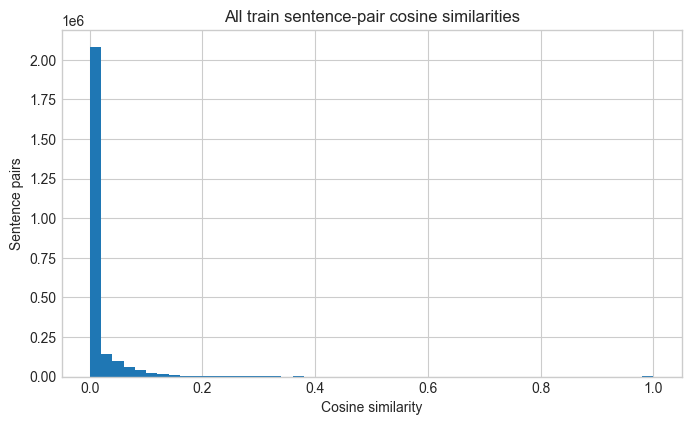

In [2]:
similarity_values = []
for topic_path in sorted(path for path in TRAIN_DIR.iterdir() if path.is_file()):
    sentences = read_topic(topic_path)
    vectors = calculate_tfidf_vectors(sentences)
    _, similarities = build_sentence_graph(vectors, 0.0)
    for left in range(len(similarities)):
        similarity_values.extend(similarities[left][left + 1:])

sorted_similarities = sorted(similarity_values)
def percentile(values, ratio):
    return values[round((len(values) - 1) * ratio)]
percentiles = {name: percentile(sorted_similarities, ratio)
               for name, ratio in [('P50', .50), ('P75', .75), ('P90', .90), ('P95', .95)]}
print(percentiles)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(similarity_values, bins=50, edgecolor='none')
ax.set(title='All train sentence-pair cosine similarities', xlabel='Cosine similarity', ylabel='Sentence pairs')
fig.savefig(CHART_DIR / '02-similarity-distribution.png', dpi=160, bbox_inches='tight')
plt.show()

### 2. Sweep thresholds

In [3]:
THRESHOLDS = [0.00, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
configs = [TextRankConfig(similarity_threshold=value) for value in THRESHOLDS]
threshold_details, threshold_summaries = run_sweep(TRAIN_DIR, REFERENCE_DIR, configs, 'train')
ranked_thresholds = rank_configurations(threshold_summaries, required_topics=50)
write_csv(CSV_DIR / '02-threshold-topic-metrics.csv', threshold_details, DETAIL_FIELDS)
write_csv(CSV_DIR / '02-threshold-summary.csv', ranked_thresholds, SUMMARY_FIELDS)
best_threshold_row = ranked_thresholds[0]
print('Best threshold:', best_threshold_row['similarity_threshold'])

Best threshold: 0.02


### 3. Plot quality and graph health

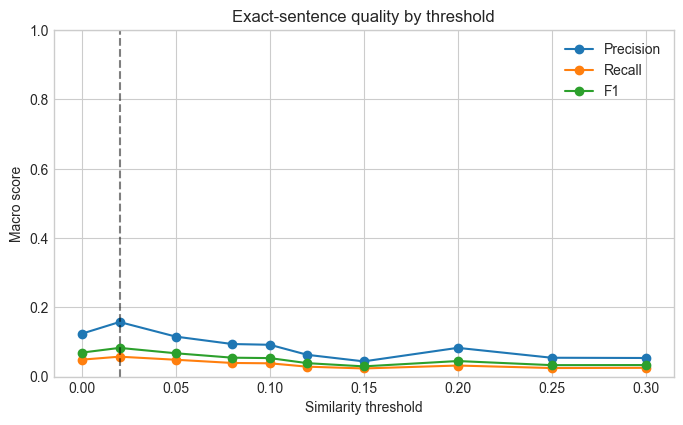

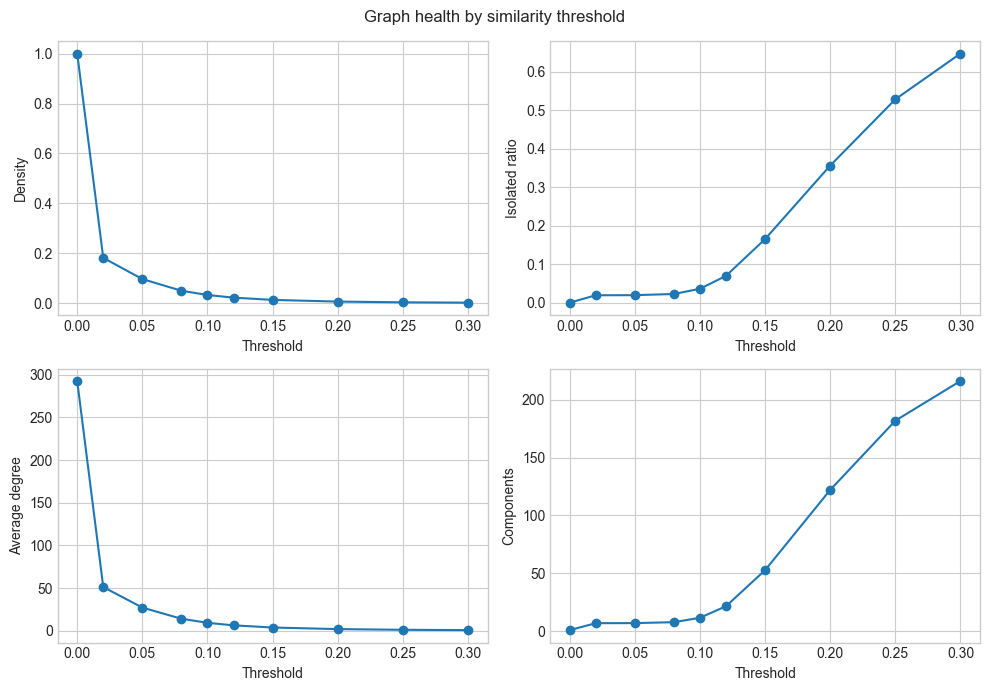

In [4]:
ordered = sorted(threshold_summaries, key=lambda row: row['similarity_threshold'])
x = [row['similarity_threshold'] for row in ordered]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, [row['macro_precision'] for row in ordered], marker='o', label='Precision')
ax.plot(x, [row['macro_recall'] for row in ordered], marker='o', label='Recall')
ax.plot(x, [row['macro_f1'] for row in ordered], marker='o', label='F1')
ax.axvline(best_threshold_row['similarity_threshold'], color='black', linestyle='--', alpha=.5)
ax.set(title='Exact-sentence quality by threshold', xlabel='Similarity threshold', ylabel='Macro score', ylim=(0, 1))
ax.legend()
fig.savefig(CHART_DIR / '02-threshold-quality.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
series = [('mean_density', 'Density'), ('mean_isolated_ratio', 'Isolated ratio'),
          ('mean_average_degree', 'Average degree'), ('mean_connected_components', 'Components')]
for ax, (field, label) in zip(axes.flat, series):
    ax.plot(x, [row[field] for row in ordered], marker='o')
    ax.set(xlabel='Threshold', ylabel=label)
fig.suptitle('Graph health by similarity threshold')
fig.tight_layout()
fig.savefig(CHART_DIR / '02-threshold-graph-health.png', dpi=160, bbox_inches='tight')
plt.show()

## Checks

Các assertion dưới đây bảo đảm artifact và dữ liệu của notebook đầy đủ.

In [5]:
assert len(threshold_summaries) == len(THRESHOLDS)
assert all(row['converged_topics'] == 50 for row in threshold_summaries)
for path in [CSV_DIR / '02-threshold-summary.csv', CSV_DIR / '02-threshold-topic-metrics.csv',
             CHART_DIR / '02-similarity-distribution.png', CHART_DIR / '02-threshold-quality.png',
             CHART_DIR / '02-threshold-graph-health.png']:
    assert path.is_file() and path.stat().st_size > 0, path
print('All threshold checks passed.')

All threshold checks passed.


## Takeaways

In [6]:
print(f"Best tested threshold={float(best_threshold_row['similarity_threshold']):.2f}, "
      f"Precision={float(best_threshold_row['macro_precision']):.4f}, "
      f"F1={float(best_threshold_row['macro_f1']):.4f}.")
print('This is the best value inside the tested threshold grid, not a universal optimum.')

Best tested threshold=0.02, Precision=0.1575, F1=0.0828.
This is the best value inside the tested threshold grid, not a universal optimum.
